In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def unpickle(file):
	with open(file, 'rb') as fo:
		dict = pickle.load(fo, encoding='bytes')
	return dict

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Load metadata to get label names
meta = unpickle('../../datasets/cifar-10-batches-py/batches.meta')
label_names = [name.decode('utf-8') for name in meta[b'label_names']]
print("Label names:", label_names)

In [ ]:
# Load first data batch and inspect its structure
batch1 = unpickle('../../datasets/cifar-10-batches-py/data_batch_1')
print("Keys:", [k.decode('utf-8') if isinstance(k, bytes) else k for k in batch1.keys()])
print("Data shape:", batch1[b'data'].shape)
print("Number of labels:", len(batch1[b'labels']))
print("Sample label:", label_names[batch1[b'labels'][0]])

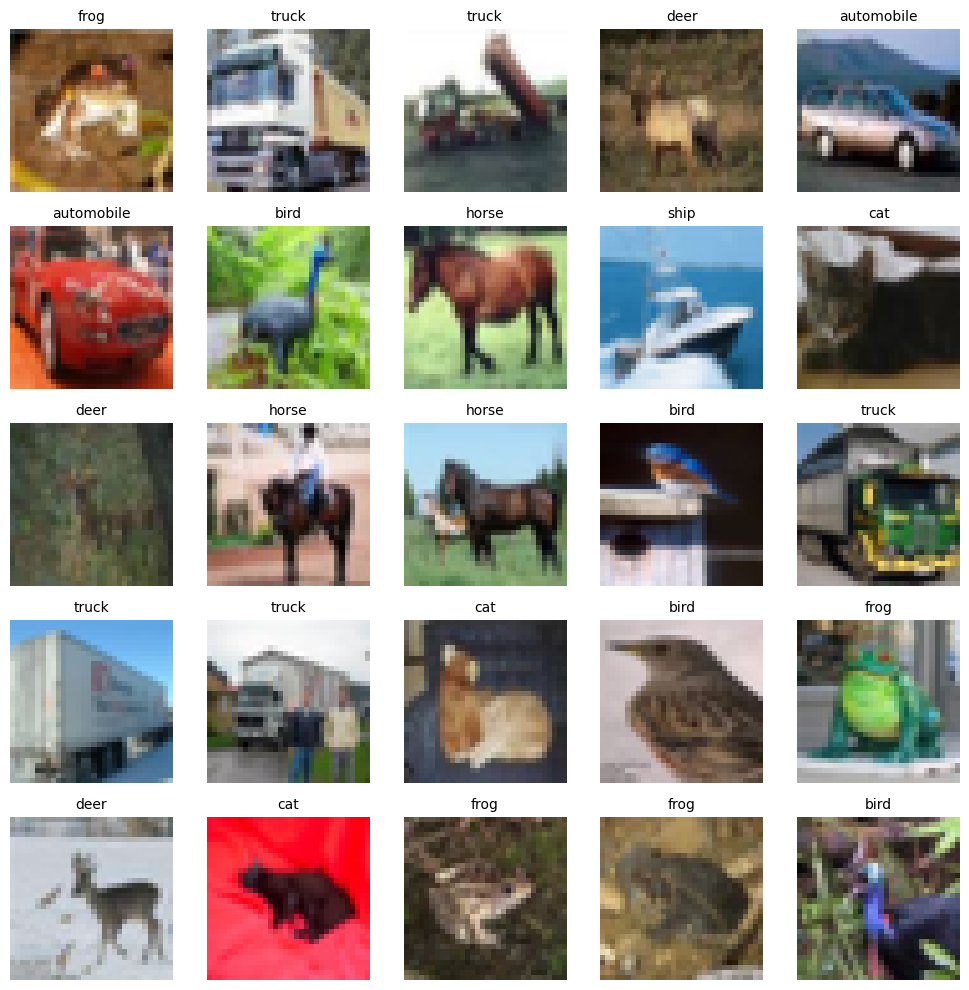

In [4]:
# Reshape and display a grid of sample images
def show_images(data, labels, n=25):
	"""Display a grid of n images from the batch."""
	cols = 5
	rows = n // cols
	fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
	for i, ax in enumerate(axes.flat):
		# CIFAR-10 images are 32x32x3, stored as 3072 flat array (R, G, B channels)
		img = data[i].reshape(3, 32, 32).transpose(1, 2, 0)
		ax.imshow(img)
		ax.set_title(label_names[labels[i]], fontsize=10)
		ax.axis('off')
	plt.tight_layout()
	plt.show()

show_images(batch1[b'data'], batch1[b'labels'])

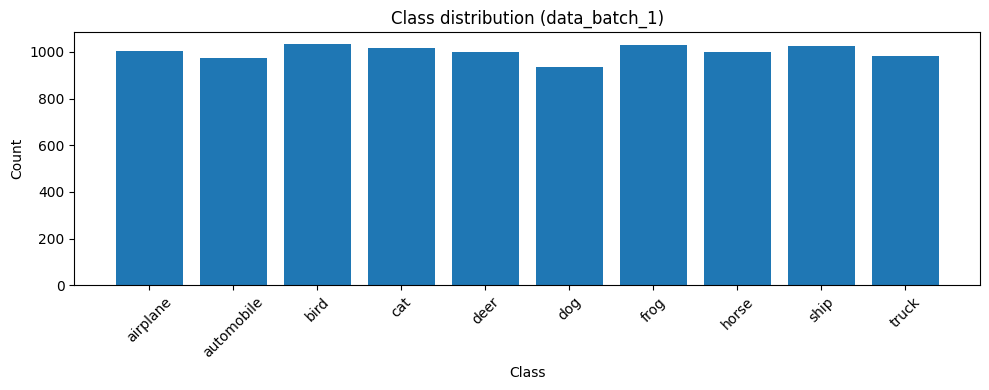

In [ ]:
counts = Counter(batch1[b'labels'])
classes = [label_names[i] for i in range(10)]
values = [counts[i] for i in range(10)]

plt.figure(figsize=(10, 4))
plt.bar(classes, values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class distribution (data_batch_1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Basic pixel statistics
data = batch1[b'data'].astype(np.float32)
print(f"Pixel value range: [{data.min()}, {data.max()}]")
print(f"Mean pixel value: {data.mean():.2f}")
print(f"Std pixel value: {data.std():.2f}")
print(f"Images per batch: {data.shape[0]}")
print(f"Total batches: 5 training + 1 test")
print(f"Total training images: {5 * data.shape[0]}")

Pixel value range: [0.0, 255.0]
Mean pixel value: 121.04
Std pixel value: 64.39
Images per batch: 10000
Total batches: 5 training + 1 test
Total training images: 50000
